# Giai đoạn 11: So sánh Công bằng Tuyệt đối trên Tập Dữ liệu Gộp MIMIC + PTB-XL (4,230 Mẫu)
Notebook này tiến hành đánh giá và so sánh tất cả các thuật toán Học máy tiêu chuẩn trên bộ dữ liệu gộp đa nguồn y tế (MIMIC-III ICU + PTB-XL 12-lead ECG):
- **Mô hình Tuyến tính (Linear)**: `Logistic Regression`, `SVM`, `LDA`, `QDA` (Sử dụng tập 16 Đặc trưng).
- **Mô hình Phi tuyến & Cây (Non-linear & Trees)**: `Decision Tree`, `Random Forest`, `Extra Trees`, `KNN`, `Naive Bayes`, `XGBoost`, `LightGBM`, `TabPFN` (Sử dụng tập 13 Đặc trưng tối ưu).

In [1]:
import os
from dotenv import load_dotenv
for env_path in ['../../.env', '.env', '../.env', 'HealthSense-ML/.env']:
    if os.path.exists(env_path):
        load_dotenv(env_path, override=True)
        break

# Cấu hình token TabPFN cố định
tabpfn_token = os.environ.get('TABPFN_TOKEN', 'tabpfn_sk_c3QkRiwEKIItD0qhyM_7N3fvYTJw1x2FAQLBMhQ3kY4')
os.environ['TABPFN_TOKEN'] = tabpfn_token

from sklearn.impute import SimpleImputer
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
import xgboost as xgb
import lightgbm as lgb

tabpfn_model = None
try:
    import tabpfn_client
    if tabpfn_token:
        tabpfn_client.set_access_token(tabpfn_token)
    tabpfn_client.init()
    from tabpfn_client import TabPFNClassifier
    tabpfn_model = TabPFNClassifier()
    print('✅ Kết nối thành công TabPFN Cloud API!')
except Exception as e:
    try:
        from tabpfn import TabPFNClassifier
        tabpfn_model = TabPFNClassifier(device='cpu')
        print('✅ Khởi tạo thành công TabPFN Local!')
    except Exception as e2:
        print(f'⚠️ Chưa nạp TabPFN: {e2}')


✅ Kết nối thành công TabPFN Cloud API!


### 1. Nạp dữ liệu Gộp MIMIC + PTB-XL & Tách tập 16 Đặc trưng vs 13 Đặc trưng

In [2]:
import os
candidates = [
    '../../data/features/combined_mimic_ptbxl_advanced.csv',
    'data/features/combined_mimic_ptbxl_advanced.csv',
    '../data/features/combined_mimic_ptbxl_advanced.csv'
]
data_path = next((p for p in candidates if os.path.exists(p)), candidates[0])

df_16 = pd.read_csv(data_path)
cols_to_drop = ['LF_HF_Ratio', 'LF_norm', 'HF_norm']
df_13 = df_16.drop(columns=cols_to_drop)

y = df_16['status']
X_16 = df_16.drop(columns=['status'])
X_13 = df_13.drop(columns=['status'])

X16_train, X16_test, y_train, y_test = train_test_split(X_16, y, test_size=0.2, random_state=42, stratify=y)
X13_train, X13_test, _, _ = train_test_split(X_13, y, test_size=0.2, random_state=42, stratify=y)

print(f'Bộ dữ liệu Combined đang dùng: {data_path}')
print(f'Tập Train: {len(y_train)} mẫu | Tập Test: {len(y_test)} mẫu')
print(f'Kích thước Tập 16 Đặc trưng: Train {X16_train.shape}, Test {X16_test.shape}')
print(f'Kích thước Tập 13 Đặc trưng: Train {X13_train.shape}, Test {X13_test.shape}')


Bộ dữ liệu Combined đang dùng: ../../data/features/combined_mimic_ptbxl_advanced.csv
Tập Train: 3384 mẫu | Tập Test: 846 mẫu
Kích thước Tập 16 Đặc trưng: Train (3384, 16), Test (846, 16)
Kích thước Tập 13 Đặc trưng: Train (3384, 13), Test (846, 13)


### 2. Huấn luyện Tất cả các Mô hình (Benchmark All Models on Combined Dataset)

In [3]:
# Nhóm 1: Mô hình Tuyến tính -> Dùng X16
linear_models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'SVM': SVC(random_state=42, probability=True),
    'LDA': LinearDiscriminantAnalysis(),
    'QDA': QuadraticDiscriminantAnalysis(reg_param=0.1)
}

# Nhóm 2: Mô hình Phi tuyến / Cây / Xác suất -> Dùng X13
nonlinear_models = {
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=300, random_state=42, class_weight='balanced'),
    'Extra Trees': ExtraTreesClassifier(n_estimators=300, random_state=42, class_weight='balanced'),
    'KNN': KNeighborsClassifier(),
    'Naive Bayes': GaussianNB(),
    'XGBoost': xgb.XGBClassifier(random_state=42, eval_metric='logloss'),
    'LightGBM': lgb.LGBMClassifier(random_state=42, verbose=-1, n_estimators=300, learning_rate=0.05, num_leaves=31)
}

if tabpfn_model is not None:
    nonlinear_models['TabPFN'] = tabpfn_model

results = []
confusion_matrices = {}

models_dir_candidates = ['../../models/fair_compare_combined', 'models/fair_compare_combined', '../models/fair_compare_combined']
models_dir = next((d for d in models_dir_candidates if os.path.exists(os.path.dirname(d))), '../../models/fair_compare_combined')
os.makedirs(models_dir, exist_ok=True)

def train_and_eval(models_dict, X_train_set, X_test_set, dataset_name):
    for name, model in models_dict.items():
        print(f'Đang huấn luyện Combined: {name} (Trên tập {dataset_name})...')
        if name == 'TabPFN':
            try:
                X_tr = X_train_set.values if hasattr(X_train_set, 'values') else X_train_set
                X_te = X_test_set.values if hasattr(X_test_set, 'values') else X_test_set
                y_tr = y_train.values if hasattr(y_train, 'values') else y_train
                y_te = y_test.values if hasattr(y_test, 'values') else y_test
                
                model.fit(X_tr, y_tr)
                y_pred = model.predict(X_te)
                
                results.append({
                    'Model': name,
                    'Dataset': dataset_name,
                    'Accuracy': accuracy_score(y_te, y_pred),
                    'Precision': precision_score(y_te, y_pred, zero_division=0),
                    'Recall': recall_score(y_te, y_pred, zero_division=0),
                    'F1-Score': f1_score(y_te, y_pred, zero_division=0)
                })
                confusion_matrices[name] = confusion_matrix(y_te, y_pred)
            except Exception as e:
                print(f'❌ Mô hình TabPFN bị lỗi khi huấn luyện: {e}')
                print('💡 Gợi ý: Hãy kiểm tra TABPFN_TOKEN tại https://ux.priorlabs.ai/account hoặc cập nhật trong file .env')
            continue
            
        model_to_run = Pipeline([('imputer', SimpleImputer(strategy='median')), ('scaler', StandardScaler()), ('classifier', model)])
        try:
            model_to_run.fit(X_train_set, y_train)
            y_pred = model_to_run.predict(X_test_set)
            
            results.append({
                'Model': name,
                'Dataset': dataset_name,
                'Accuracy': accuracy_score(y_test, y_pred),
                'Precision': precision_score(y_test, y_pred, zero_division=0),
                'Recall': recall_score(y_test, y_pred, zero_division=0),
                'F1-Score': f1_score(y_test, y_pred, zero_division=0)
            })
            confusion_matrices[name] = confusion_matrix(y_test, y_pred)
            save_path = os.path.join(models_dir, f"{name.replace(' ', '_').lower()}.pkl")
            joblib.dump(model_to_run, save_path)
        except Exception as e:
            print(f'❌ Mô hình {name} bị lỗi: {e}')

train_and_eval(linear_models, X16_train, X16_test, '16 Features')
train_and_eval(nonlinear_models, X13_train, X13_test, '13 Features')

print('\n✅ Hoàn tất huấn luyện tất cả các mô hình trên tập Combined!')


Đang huấn luyện Combined: Logistic Regression (Trên tập 16 Features)...


Đang huấn luyện Combined: SVM (Trên tập 16 Features)...


Đang huấn luyện Combined: LDA (Trên tập 16 Features)...
Đang huấn luyện Combined: QDA (Trên tập 16 Features)...
Đang huấn luyện Combined: Decision Tree (Trên tập 13 Features)...
Đang huấn luyện Combined: Random Forest (Trên tập 13 Features)...


Đang huấn luyện Combined: Extra Trees (Trên tập 13 Features)...


Đang huấn luyện Combined: KNN (Trên tập 13 Features)...
Đang huấn luyện Combined: Naive Bayes (Trên tập 13 Features)...
Đang huấn luyện Combined: XGBoost (Trên tập 13 Features)...


...

00:02 Predicting... \

00:02 Predicting... |

00:03 Predicting... /

00:03 Predicting... Done!



✅ Hoàn tất huấn luyện tất cả các mô hình trên tập Combined!


### 3. Bảng Kết quả So sánh Đánh giá (Combined Ranking Table)

In [4]:
from IPython.display import display
df_results = pd.DataFrame(results).sort_values(by="F1-Score", ascending=False).reset_index(drop=True)
display(df_results)
print('\nBẢNG KẾT QUẢ SO SÁNH CÁC MÔ HÌNH TRÊN TẬP GỘP (COMBINED):\n')
print(df_results.to_string(index=False))


,Model,Dataset,Accuracy,Precision,Recall,F1-Score
0,TabPFN,13 Features,0.951537,0.944186,0.959811,0.951934
1,SVM,16 Features,0.934988,0.907080,0.969267,0.937143
2,KNN,13 Features,0.934988,0.914414,0.959811,0.936563
3,XGBoost,13 Features,0.934988,0.936019,0.933806,0.934911
4,Random Forest,13 Features,0.932624,0.927570,0.938534,0.933020
5,QDA,16 Features,0.931442,0.917620,0.947991,0.932558
6,Extra Trees,13 Features,0.930260,0.915525,0.947991,0.931475
7,Logistic Regression,16 Features,0.921986,0.908467,0.938534,0.923256
8,LightGBM,13 Features,0.921986,0.921986,0.921986,0.921986
9,LDA,16 Features,0.914894,0.892617,0.943262,0.917241



BẢNG KẾT QUẢ SO SÁNH CÁC MÔ HÌNH TRÊN TẬP GỘP (COMBINED):

              Model     Dataset  Accuracy  Precision   Recall  F1-Score
             TabPFN 13 Features  0.951537   0.944186 0.959811  0.951934
                SVM 16 Features  0.934988   0.907080 0.969267  0.937143
                KNN 13 Features  0.934988   0.914414 0.959811  0.936563
            XGBoost 13 Features  0.934988   0.936019 0.933806  0.934911
      Random Forest 13 Features  0.932624   0.927570 0.938534  0.933020
                QDA 16 Features  0.931442   0.917620 0.947991  0.932558
        Extra Trees 13 Features  0.930260   0.915525 0.947991  0.931475
Logistic Regression 16 Features  0.921986   0.908467 0.938534  0.923256
           LightGBM 13 Features  0.921986   0.921986 0.921986  0.921986
                LDA 16 Features  0.914894   0.892617 0.943262  0.917241
      Decision Tree 13 Features  0.893617   0.901205 0.884161  0.892601
        Naive Bayes 13 Features  0.847518   0.897297 0.784870  0.837327


### 4. Trực quan hóa Ma trận Nhầm lẫn (Confusion Matrices on Combined Dataset)

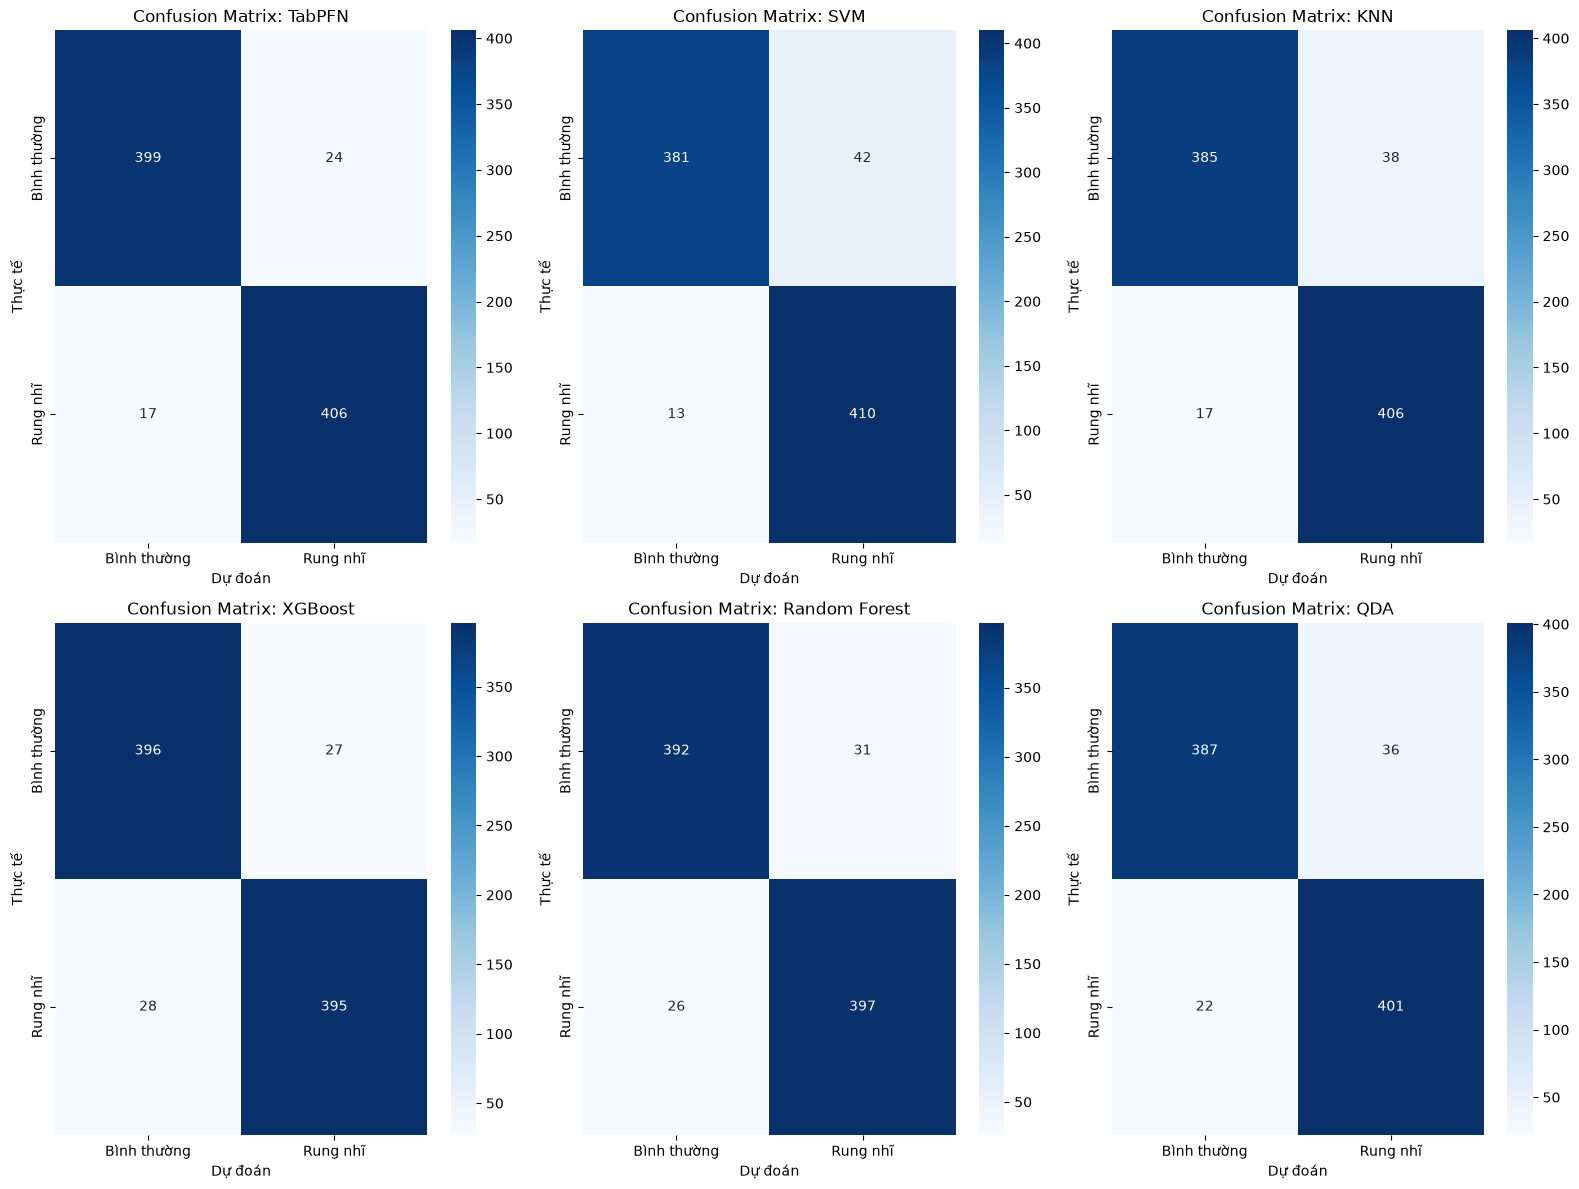

In [5]:
plt.figure(figsize=(16, 12))
top_models = df_results['Model'].head(6).tolist()
for i, model_name in enumerate(top_models, 1):
    if model_name in confusion_matrices:
        plt.subplot(2, 3, i)
        sns.heatmap(confusion_matrices[model_name], annot=True, fmt='d', cmap='Blues',
                    xticklabels=['Bình thường', 'Rung nhĩ'],
                    yticklabels=['Bình thường', 'Rung nhĩ'])
        plt.title(f'Confusion Matrix: {model_name}')
        plt.ylabel('Thực tế')
        plt.xlabel('Dự đoán')
plt.tight_layout()
plt.show()
